# Nonlinear SE(2) GBP Test

This notebook exercises the new `gbp_nonlinear.py` path:

1. Build a nonlinear SE(2) graph with `build_nonlinear_se2_pose_graph()`.
2. Freeze one linearization and compare inner GBP deltas against the exact direct linear solve.
3. Build a GTSAM baseline from the **exact same noisy factors and initial poses** already stored in the nonlinear GBP graph.
4. Run several outer iterations and compare the nonlinear GBP result against the GTSAM batch baseline.

Important: this notebook does **not** use the older GTSAM builder from `test.ipynb`, because that path can accidentally create a slightly different graph due to duplicate noise generation or ordering differences.

Default hyper-parameters below follow the benchmark setting you requested. If the run is too slow, reduce `N` from `512` to `128`.

## Linear Benchmark Blocks

These are **linear surrogate** benchmark blocks placed before the nonlinear SE(2) test.

1. `Jacobi method`: matrix multigrid on the same raylib hierarchy, using exact `RAP`.
2. `Algebraic GBP multigrid`: current local raylib algebraic GBP baseline comparisons.
3. `SVD residual multigrid`: the earlier SVD-based residual abstraction benchmark.

They are intentionally kept separate from the nonlinear SE(2) notebook below.


In [1]:
import pathlib
import sys
import numpy as np

WORKSPACE_ROOT = pathlib.Path('/home/yuzhou/Desktop/abstraction-recovery')
if str(WORKSPACE_ROOT) not in sys.path:
    sys.path.insert(0, str(WORKSPACE_ROOT))
LOCAL_RAYLIB_ROOT = WORKSPACE_ROOT / 'svd_abstraction' / 'raylib_gbp_local'
if str(LOCAL_RAYLIB_ROOT) not in sys.path:
    sys.path.insert(0, str(LOCAL_RAYLIB_ROOT))

for prefix in ('gbp', 'amg'):
    for name, module in list(sys.modules.items()):
        if name != prefix and not name.startswith(prefix + '.'):
            continue
        if module is None:
            sys.modules.pop(name, None)
            continue
        module_file = getattr(module, '__file__', None)
        module_paths = list(getattr(module, '__path__', []))
        in_local = (module_file is not None and str(module_file).startswith(str(LOCAL_RAYLIB_ROOT))) or any(str(path).startswith(str(LOCAL_RAYLIB_ROOT)) for path in module_paths)
        if not in_local:
            sys.modules.pop(name, None)

for stale_name in [
    'svd_abstraction.raylib_same_hierarchy_jacobi_experiment',
    'svd_abstraction.raylib_local_eta_prolongation_validation',
    'svd_abstraction.raylib_local_sequential_experiment',
    'svd_abstraction.compare_convergence',
]:
    sys.modules.pop(stale_name, None)

from svd_abstraction.raylib_same_hierarchy_jacobi_experiment import (
    base_mean_vector,
    build_exact_rap_levels,
    build_transfer_operators,
    run_base_jacobi,
    run_multilevel_jacobi,
    run_two_level_jacobi,
)
from svd_abstraction.raylib_local_eta_prolongation_validation import (
    build_hierarchy as build_raylib_hierarchy,
    build_slam_graph as build_raylib_slam_graph,
    exact_mean as exact_raylib_mean,
)
from svd_abstraction.raylib_local_sequential_experiment import (
    run_base as run_raylib_base,
    run_two_level as run_raylib_two_level,
)
from svd_abstraction.compare_convergence import (
    run_base_until_converged as run_svd_base_until_converged,
    run_vcycle_until_converged as run_svd_vcycle_until_converged,
)
from svd_abstraction.pose_graph import build_noisy_pose_graph as build_svd_pose_graph
from svd_abstraction.pose_graph import make_slam_like_graph as make_svd_slam_like_graph


def print_metric_points(name, conv, relerrs, points):
    print(f'{name} conv: {conv}')
    for pt in points:
        if pt < len(relerrs):
            print(f'  {pt}: {relerrs[pt]}')


### 1. Jacobi Method Test Block


In [4]:
J_N = 512
J_OMEGA = 1.0
J_MAX_ITERS = 3000
J_MAX_CYCLES = 1500
J_TOL = 1e-6
J_POINTS = [0, 1, 2, 5, 10, 20, 50, 100, 200, 500]

jacobi_graph = build_raylib_slam_graph(n=J_N, seed=0)
J_x0 = base_mean_vector(jacobi_graph)
J_x_star = exact_raylib_mean(jacobi_graph)
build_raylib_hierarchy(jacobi_graph)
J_b0, J_a0 = jacobi_graph.joint_distribution_inf_level(0)
J_b0 = np.asarray(J_b0, dtype=float)
J_a0 = np.asarray(J_a0, dtype=float)
J_r, J_p = build_transfer_operators(jacobi_graph, coarse_level=1)
J_levels = build_exact_rap_levels(jacobi_graph)
J_a1_rap = J_r @ J_a0 @ J_p

base_j_conv, base_j_relerrs = run_base_jacobi(a0=J_a0, b0=J_b0, x0=J_x0, x_star=J_x_star, omega=J_OMEGA, max_iters=J_MAX_ITERS, tol=J_TOL, block_dof=None)
two_j_conv, two_j_relerrs = run_two_level_jacobi(a0=J_a0, b0=J_b0, a1=J_a1_rap, r=J_r, p=J_p, x0=J_x0, x_star=J_x_star, omega=J_OMEGA, max_cycles=J_MAX_CYCLES, tol=J_TOL, coarse_sweeps=2, block_dof=None)
multi_j_conv, multi_j_relerrs = run_multilevel_jacobi(levels=J_levels, b0=J_b0, x0=J_x0, x_star=J_x_star, omega=J_OMEGA, max_cycles=J_MAX_CYCLES, tol=J_TOL, block_dof=None)

print_metric_points('base_jacobi', base_j_conv, base_j_relerrs, J_POINTS)
print_metric_points('two_level_jacobi_exact_rap', two_j_conv, two_j_relerrs, J_POINTS)
print_metric_points('multilevel_jacobi_exact_rap', multi_j_conv, multi_j_relerrs, J_POINTS)


base_jacobi conv: None
  0: 0.9899437630168586
  1: 0.9708564239390473
  2: 0.9647571953457639
  5: 0.9464611920416603
  10: 0.9213776022805307
  20: 0.8788761980677168
  50: 0.7785094488320674
  100: 0.6535207012807532
  200: 0.47999522224946034
  500: 0.2093863161632138
two_level_jacobi_exact_rap conv: 849
  0: 0.9899437630168586
  1: 0.9278309561281618
  2: 0.88663567379157
  5: 0.7989860830765764
  10: 0.7022877658724407
  20: 0.5712380142771917
  50: 0.334610302238437
  100: 0.14831083676874998
  200: 0.03050130880400934
  500: 0.00025901074601566423
multilevel_jacobi_exact_rap conv: 690
  0: 0.9899437630168586
  1: 0.8948749948295164
  2: 0.8281078713364382
  5: 0.7227077082238395
  10: 0.6255364523060136
  20: 0.49357471201776476
  50: 0.26501018895998174
  100: 0.10024847373067819
  200: 0.0144254910174972
  500: 4.10054833653618e-05


### 2. Algebraic GBP Multigrid Test Block


In [7]:
A_N = 100
A_WARMUP = 0
A_MAX_ITERS = 1200
A_MAX_CYCLES = 600
A_TOL = 1e-6
A_POINTS = [0, 1, 2, 5, 10, 20, 50, 100, 200, 300]

base_sync_conv, base_sync_relerrs = run_raylib_base(mode='synchronous', n=A_N, warmup=A_WARMUP, max_iters=A_MAX_ITERS, tol=A_TOL)
#base_seq_conv, base_seq_relerrs = run_raylib_base(mode='sequential', n=A_N, warmup=A_WARMUP, max_iters=A_MAX_ITERS, tol=A_TOL)
two_sync_conv, two_sync_relerrs = run_raylib_two_level(base_mode='synchronous', coarse_mode='synchronous', n=A_N, warmup=A_WARMUP, max_cycles=A_MAX_CYCLES, tol=A_TOL)
#two_seqsync_conv, two_seqsync_relerrs = run_raylib_two_level(base_mode='sequential', coarse_mode='synchronous', n=A_N, warmup=A_WARMUP, max_cycles=A_MAX_CYCLES, tol=A_TOL)

print_metric_points('base_sync_gbp', base_sync_conv, base_sync_relerrs, A_POINTS)
#print_metric_points('base_seq_gbp', base_seq_conv, base_seq_relerrs, A_POINTS)
print_metric_points('two_level_sync_sync_gbp', two_sync_conv, two_sync_relerrs, A_POINTS)
#print_metric_points('two_level_seq_sync_gbp', two_seqsync_conv, two_seqsync_relerrs, A_POINTS)


base_sync_gbp conv: 1075
  0: 0.9921103123579439
  1: 0.966033364551874
  2: 0.9232042495792373
  5: 0.5156612447142038
  10: 0.1571426157103539
  20: 0.010051383087329002
  50: 0.007758895235689564
  100: 0.005012004553895016
  200: 0.0020913605887838953
  300: 0.0008726626372318264
two_level_sync_sync_gbp conv: 334
  0: 0.9921103123579439
  1: 0.9661277746954173
  2: 0.8719651270562147
  5: 0.5946049787095097
  10: 0.44508218605819555
  20: 0.2936356336631998
  50: 0.08810707746869553
  100: 0.011851548232950258
  200: 0.00021443162144931072
  300: 3.879739047547752e-06


### 3. SVD Residual Multigrid Test Block


In [ ]:
SVD_N = 30
SVD_STEP_SIZE = 15.0
SVD_LOOP_PROB = 0.08
SVD_LOOP_RADIUS = 40.0
SVD_PRIOR_PROP = 0.15
SVD_PRIOR_SIGMA = 6.0
SVD_ODOM_SIGMA = 3.0
SVD_GROUP_SIZE = 5
SVD_R = 2
SVD_WARMUP = 5
SVD_NUM_LEVELS = 2
SVD_TOL = 1e-6
SVD_MAX_BASE_ITERS = 2000
SVD_MAX_V_CYCLES = 500
SVD_POINTS = [0, 1, 2, 5, 10, 20, 50, 100]

svd_nodes, svd_edges = make_svd_slam_like_graph(N=SVD_N, step_size=SVD_STEP_SIZE, loop_prob=SVD_LOOP_PROB, loop_radius=SVD_LOOP_RADIUS, prior_prop=SVD_PRIOR_PROP, seed=0)
svd_exact_graph = build_svd_pose_graph(svd_nodes, svd_edges, prior_sigma=SVD_PRIOR_SIGMA, odom_sigma=SVD_ODOM_SIGMA, tiny_prior=1e-12, seed=0)
svd_x_star, _ = svd_exact_graph.joint_distribution_cov()
svd_base_graph = build_svd_pose_graph(svd_nodes, svd_edges, prior_sigma=SVD_PRIOR_SIGMA, odom_sigma=SVD_ODOM_SIGMA, tiny_prior=1e-12, seed=0)
svd_vcycle_graph = build_svd_pose_graph(svd_nodes, svd_edges, prior_sigma=SVD_PRIOR_SIGMA, odom_sigma=SVD_ODOM_SIGMA, tiny_prior=1e-12, seed=0)

svd_base_conv, svd_base_err, svd_base_hist = run_svd_base_until_converged(svd_base_graph, svd_x_star, tol=SVD_TOL, max_iters=SVD_MAX_BASE_ITERS)
(svd_v_cycles, svd_actual_levels, svd_base_sweeps, svd_total_sweeps, svd_direct_solves, svd_v_err, svd_v_hist, svd_v_stats) = run_svd_vcycle_until_converged(svd_vcycle_graph, svd_nodes, svd_x_star, tol=SVD_TOL, max_cycles=SVD_MAX_V_CYCLES, group_size=SVD_GROUP_SIZE, r_reduced=SVD_R, basis_source='belief_covariance', eta_assignment_mode='all_in_prior', warmup=SVD_WARMUP, num_levels=SVD_NUM_LEVELS, top_level_solver='iterative')

print(f'svd_base_gbp conv: {svd_base_conv}, final_err: {svd_base_err}')
for pt in SVD_POINTS:
    if pt < len(svd_base_hist):
        print(f'  base {pt}: {svd_base_hist[pt]}')
print(f'svd_residual_vcycle conv: {svd_v_cycles}, levels: {svd_actual_levels}, base_sweeps: {svd_base_sweeps}, total_iter_sweeps: {svd_total_sweeps}, final_err: {svd_v_err}')
for pt in SVD_POINTS:
    if pt < len(svd_v_hist):
        print(f'  vcycle {pt}: {svd_v_hist[pt]}')


In [23]:
import sys
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "gbp").exists() and (ROOT / "hierarchy_liegroup" / "gbp").exists():
    ROOT = ROOT / "hierarchy_liegroup"
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from gbp.gbp_nonlinear import (
    BetweenSE2Factor,
    PriorSE2Factor,
    build_nonlinear_se2_pose_graph,
)
from utils.graphs import make_slam_like_graph

np.set_printoptions(precision=4, suppress=True)

try:
    import gtsam
    from gtsam import symbol
except ModuleNotFoundError:
    gtsam = None
    symbol = None
    print("GTSAM is not installed in this environment; GTSAM comparison cells will be skipped.")

In [24]:
def wrap_angle(a):
    return np.arctan2(np.sin(a), np.cos(a))


def se2_sse_from_arrays(est, gt):
    diff = np.array(est, dtype=float) - np.array(gt, dtype=float)
    diff[:, 2] = wrap_angle(diff[:, 2])
    return float(np.sum(diff * diff))


def nonlinear_graph_status_array(graph):
    arr = np.zeros((graph.n_var_nodes, 3), dtype=float)
    for i, var in enumerate(graph.var_nodes):
        t = var.status.translation()
        arr[i, 0] = float(t[0])
        arr[i, 1] = float(t[1])
        arr[i, 2] = float(var.status.angle())
    return arr


def nonlinear_graph_gt_array(graph):
    arr = np.zeros((graph.n_var_nodes, 3), dtype=float)
    for i, var in enumerate(graph.var_nodes):
        t = var.GT.translation()
        arr[i, 0] = float(t[0])
        arr[i, 1] = float(t[1])
        arr[i, 2] = float(var.GT.angle())
    return arr


def values_to_array_pose2(values, n):
    arr = np.zeros((n, 3), dtype=float)
    for key in values.keys():
        s = gtsam.Symbol(key)
        if s.chr() != ord("x"):
            continue
        idx = int(s.index())
        pose = values.atPose2(key)
        arr[idx, 0] = pose.x()
        arr[idx, 1] = pose.y()
        arr[idx, 2] = pose.theta()
    return arr


def build_gtsam_from_nonlinear_graph(nl_graph):
    if gtsam is None:
        raise RuntimeError("GTSAM is not installed")

    graph = gtsam.NonlinearFactorGraph()
    initial = gtsam.Values()

    def key(i):
        return symbol("x", int(i))

    def info_model(omega):
        return gtsam.noiseModel.Gaussian.Information(np.array(omega, dtype=float))

    for var in nl_graph.var_nodes:
        t = var.status.translation()
        initial.insert(
            key(var.variableID),
            gtsam.Pose2(float(t[0]), float(t[1]), float(var.status.angle())),
        )

    for factor in nl_graph.factors:
        model = info_model(factor.measurement_lambda)

        if isinstance(factor, PriorSE2Factor):
            i = factor.adj_var_nodes[0].variableID
            z = factor.measurement
            tz = z.translation()
            graph.add(
                gtsam.PriorFactorPose2(
                    key(i),
                    gtsam.Pose2(float(tz[0]), float(tz[1]), float(z.angle())),
                    model,
                )
            )

        elif isinstance(factor, BetweenSE2Factor):
            i = factor.adj_var_nodes[0].variableID
            j = factor.adj_var_nodes[1].variableID
            z = factor.measurement
            tz = z.translation()
            graph.add(
                gtsam.BetweenFactorPose2(
                    key(i),
                    key(j),
                    gtsam.Pose2(float(tz[0]), float(tz[1]), float(z.angle())),
                    model,
                )
            )
        else:
            raise TypeError(f"Unsupported factor type: {type(factor)}")

    return graph, initial


In [25]:
# Problem setup
N = 512
step_size = 25
loop_prob = 0.05
loop_radius = 50
prior_prop = 0.02
prior_sigma = 1.0
odom_sigma = 1.0
loop_sigma = 10.0
theta_ratio = 0.01
seed = 201

inner_iters = 100
outer_iters = 10
step_size_outer = 1.0

nodes, edges = make_slam_like_graph(
    N=N,
    step_size=step_size,
    loop_prob=loop_prob,
    loop_radius=loop_radius,
    prior_prop=prior_prop,
    seed=seed,
)

nl_graph = build_nonlinear_se2_pose_graph(
    nodes,
    edges,
    prior_sigma=prior_sigma,
    odom_sigma=odom_sigma,
    loop_sigma=loop_sigma,
    theta_ratio=theta_ratio,
    seed=seed,
    message_damping=0.0,
    init_mode="chain",
)

gt_arr = nonlinear_graph_gt_array(nl_graph)
init_arr = nonlinear_graph_status_array(nl_graph)

print("n_vars:", nl_graph.n_var_nodes)
print("n_factors:", nl_graph.n_factor_nodes)
print("theta_ratio:", theta_ratio)
print("initial SE2 SSE to GT:", se2_sse_from_arrays(init_arr, gt_arr))

n_vars: 512
n_factors: 589
theta_ratio: 0.01
initial SE2 SSE to GT: 84435.91417205069


direct delta norm: 240.37265572556498
GBP delta error to direct after inner loop: 5.649712317364223
linear residual norm after inner loop: 7.701174040300739


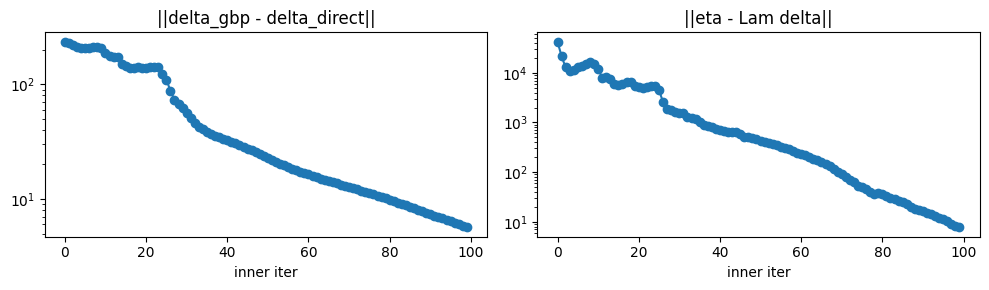

In [27]:
# Freeze one linearization and compare inner GBP against the exact direct linear solve.
nl_graph.relinearise_factors(reset_messages="full")
direct_delta = nl_graph.direct_solve_delta()

delta_error_hist = []
linear_residual_hist = []

for _ in range(inner_iters):
    nl_graph.inner_iteration()
    delta_error_hist.append(nl_graph.delta_error_to_direct())
    linear_residual_hist.append(nl_graph.linear_residual_norm())

print("direct delta norm:", float(np.linalg.norm(direct_delta)))
print("GBP delta error to direct after inner loop:", delta_error_hist[-1])
print("linear residual norm after inner loop:", linear_residual_hist[-1])

plt.figure(figsize=(10, 3))
plt.subplot(1, 2, 1)
plt.plot(delta_error_hist, marker="o")
plt.title("||delta_gbp - delta_direct||")
plt.xlabel("inner iter")
plt.yscale("log")

plt.subplot(1, 2, 2)
plt.plot(linear_residual_hist, marker="o")
plt.title("||eta - Lam delta||")
plt.xlabel("inner iter")
plt.yscale("log")
plt.tight_layout()
plt.show()

In [19]:
# Build a GTSAM baseline from the exact same noisy factors + exact same initial poses.
gtsam_result = None
gtsam_arr = None

if gtsam is None:
    print("Skipping GTSAM baseline because gtsam is not installed in this environment.")
else:
    gtsam_graph, gtsam_initial = build_gtsam_from_nonlinear_graph(nl_graph)

    gtsam_init_arr = values_to_array_pose2(gtsam_initial, nl_graph.n_var_nodes)
    print("initial array mismatch between nonlinear GBP graph and GTSAM initial:", float(np.linalg.norm(gtsam_init_arr - init_arr)))

    params = gtsam.LevenbergMarquardtParams()
    params.setVerbosityLM("SILENT")
    params.setMaxIterations(200)
    params.setRelativeErrorTol(1e-9)
    params.setAbsoluteErrorTol(1e-9)
    params.setlambdaInitial(1e-3)

    optimizer = gtsam.LevenbergMarquardtOptimizer(gtsam_graph, gtsam_initial, params)
    gtsam_result = optimizer.optimize()
    gtsam_arr = values_to_array_pose2(gtsam_result, nl_graph.n_var_nodes)

    print("GTSAM final graph error:", float(gtsam_graph.error(gtsam_result)))
    print("GTSAM final SE2 SSE to GT:", se2_sse_from_arrays(gtsam_arr, gt_arr))

initial array mismatch between nonlinear GBP graph and GTSAM initial: 2.5105140857293913e-16
GTSAM final graph error: 97.58941051372865
GTSAM final SE2 SSE to GT: 22271.6130740978


{'outer_iter': 1, 'sse_to_gt': 21735.7012991133, 'sse_to_gtsam': 36.597542439159994}
{'outer_iter': 2, 'sse_to_gt': 21735.783798874327, 'sse_to_gtsam': 36.592586211451994}
{'outer_iter': 3, 'sse_to_gt': 21735.718846349257, 'sse_to_gtsam': 36.59260185935341}
{'outer_iter': 4, 'sse_to_gt': 21735.797727950434, 'sse_to_gtsam': 36.590996341919535}
{'outer_iter': 5, 'sse_to_gt': 21735.819069841433, 'sse_to_gtsam': 36.591343420708775}
{'outer_iter': 6, 'sse_to_gt': 21735.74575709524, 'sse_to_gtsam': 36.59184474068583}
{'outer_iter': 7, 'sse_to_gt': 21735.78152758335, 'sse_to_gtsam': 36.59210146192916}
{'outer_iter': 8, 'sse_to_gt': 21736.02361230794, 'sse_to_gtsam': 36.53394939099066}
{'outer_iter': 9, 'sse_to_gt': 21735.70138405115, 'sse_to_gtsam': 36.59318167794899}
{'outer_iter': 10, 'sse_to_gt': 21735.77358067198, 'sse_to_gtsam': 36.59136248953664}


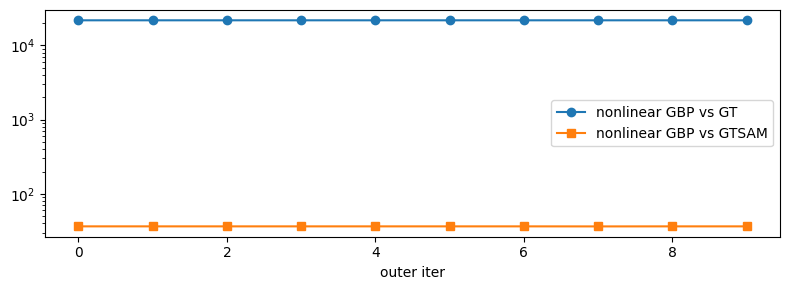

In [31]:
# Run several outer iterations and compare against GT and the exact-same GTSAM baseline.
outer_history = []

for outer in range(outer_iters):
    nl_graph.outer_iteration(
        inner_iters=inner_iters,
        step_size=step_size_outer,
        reset_messages="full",
    )

    est_arr = nonlinear_graph_status_array(nl_graph)
    entry = {
        "outer_iter": outer + 1,
        "sse_to_gt": se2_sse_from_arrays(est_arr, gt_arr),
    }
    if gtsam_arr is not None:
        entry["sse_to_gtsam"] = se2_sse_from_arrays(est_arr, gtsam_arr)

    outer_history.append(entry)
    print(entry)

outer_sse_to_gt = [d["sse_to_gt"] for d in outer_history]
plt.figure(figsize=(8, 3))
plt.plot(outer_sse_to_gt, marker="o", label="nonlinear GBP vs GT")
if gtsam_arr is not None:
    outer_sse_to_gtsam = [d["sse_to_gtsam"] for d in outer_history]
    plt.plot(outer_sse_to_gtsam, marker="s", label="nonlinear GBP vs GTSAM")
plt.xlabel("outer iter")
plt.yscale("log")
plt.legend()
plt.tight_layout()
plt.show()

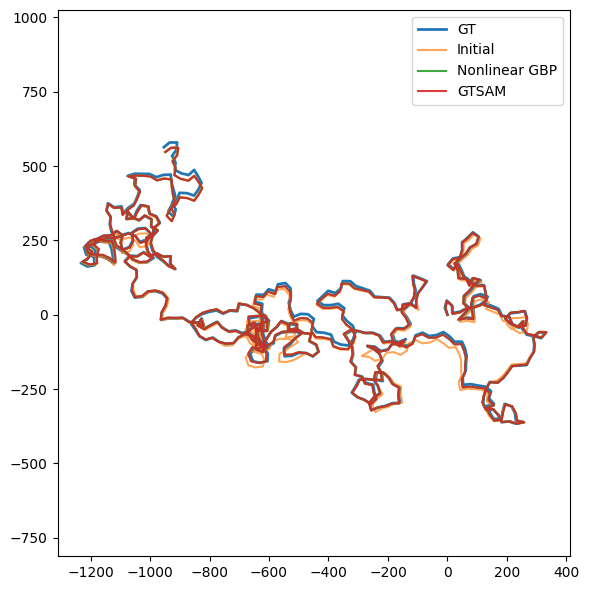

Final nonlinear GBP SE2 SSE to GT: 21735.77358067198
Final nonlinear GBP SE2 SSE to GTSAM: 36.59136248953664


In [32]:
# Final trajectory comparison in XY.
final_arr = nonlinear_graph_status_array(nl_graph)

plt.figure(figsize=(6, 6))
plt.plot(gt_arr[:, 0], gt_arr[:, 1], label="GT", linewidth=2)
plt.plot(init_arr[:, 0], init_arr[:, 1], label="Initial", alpha=0.7)
plt.plot(final_arr[:, 0], final_arr[:, 1], label="Nonlinear GBP", alpha=0.9)
if gtsam_arr is not None:
    plt.plot(gtsam_arr[:, 0], gtsam_arr[:, 1], label="GTSAM", alpha=0.9)
plt.axis("equal")
plt.legend()
plt.tight_layout()
plt.show()

print("Final nonlinear GBP SE2 SSE to GT:", se2_sse_from_arrays(final_arr, gt_arr))
if gtsam_arr is not None:
    print("Final nonlinear GBP SE2 SSE to GTSAM:", se2_sse_from_arrays(final_arr, gtsam_arr))